# Surface complexation model of dolomite surface charge

A constant-capacitance surface complexation model (SCM) applied to the measured base-run
compositions. The dolomite surface carries two site types, carbonate ($>$CO$_3$) and metal ($>$MeOH,
Me = Ca, Mg), reacting through six intrinsic surface reactions. The aqueous speciation is solved first;
its free-ion activities of H$^+$, Ca$^{2+}$, Mg$^{2+}$ and CO$_3^{2-}$ drive the surface reactions, and
the surface potential is found self-consistently with the constant-capacitance layer. Intrinsic surface
constants and site densities are taken from the dolomite SCM literature.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

FARADAY = 96485.33212; GAS_CONSTANT = 8.31446261815324; TEMPERATURE_K = 298.15
F_OVER_RT = FARADAY / (GAS_CONSTANT * TEMPERATURE_K)
DAVIES_A, DAVIES_B = 0.5092, 0.3
LOG_K_HENRY, LOG_K_H2CO3 = -1.468, 16.681
T_CO3, T_CA, T_MG = 14.0e-6, 7.0e-6, 7.0e-6      # site densities, mol/m2
ALPHA = 0.004                                    # capacitance = sqrt(I)/ALPHA

# intrinsic log K of the six surface reactions:
#   1  >CO3H         = >CO3-      + H+
#   2  >CO3H  + Me2+ = >CO3Me+    + H+
#   3  >MeOH         = >MeO-      + H+
#   4  >MeOH  + H+   = >MeOH2+
#   5  >MeOH + CO3(2-) + 2H+ = >MeHCO3 + H2O
#   6  >MeOH + CO3(2-) +  H+ = >MeCO3- + H2O
LOG_K = {(1,"Ca"):-4.8,(1,"Mg"):-4.8,(2,"Ca"):-1.8,(2,"Mg"):-2.0,(3,"Ca"):-12.0,(3,"Mg"):-12.0,
         (4,"Ca"):11.5,(4,"Mg"):10.6,(5,"Ca"):24.0,(5,"Mg"):23.5,(6,"Ca"):16.6,(6,"Mg"):15.4}

AQUEOUS = {"OH-":(-1,{"H":-1},-13.997),"HCO3-":(-1,{"H":1,"CO3":1},10.329),
    "H2CO3*":(0,{"H":2,"CO3":1},16.681),"CaHCO3+":(1,{"H":1,"Ca":1,"CO3":1},11.435),
    "CaCO3":(0,{"Ca":1,"CO3":1},3.224),"CaOH+":(1,{"H":-1,"Ca":1},-12.780),
    "MgHCO3+":(1,{"H":1,"Mg":1,"CO3":1},11.399),"MgCO3":(0,{"Mg":1,"CO3":1},2.980),
    "MgOH+":(1,{"H":-1,"Mg":1},-11.440),"NaHCO3":(0,{"H":1,"CO3":1,"Na":1},10.079),
    "NaCO3-":(-1,{"CO3":1,"Na":1},1.270),"NaOH":(0,{"H":-1,"Na":1},-14.180)}
COMPONENT_CHARGE = {"H":1,"Ca":2,"Mg":2,"CO3":-2,"Na":1}
CHARGES = {**COMPONENT_CHARGE, **{k:v[0] for k,v in AQUEOUS.items()}, "Cl-":-1}

In [2]:
def davies_gamma(charge, I):
    if charge == 0: return 1.0
    r = np.sqrt(I)
    return 10.0**(-DAVIES_A*charge**2*(r/(1.0+r) - DAVIES_B*I))

def complexes_from_components(fa, I):
    out = {}
    for name,(ch,st,lk) in AQUEOUS.items():
        la = lk + sum(n*np.log10(fa[c]) for c,n in st.items())
        out[name] = 10.0**la / davies_gamma(ch, I)
    return out

def component_totals(fc, cx):
    t = dict(fc)
    for name,(_c,st,_l) in AQUEOUS.items():
        for comp,n in st.items(): t[comp] += n*cx[name]
    return t

def speciate(pH, ca_tot, mg_tot, nacl, sum_co2=None, pco2=None,
             max_outer=200, exponent=0.7, tol=1e-14):
    if (sum_co2 is None) == (pco2 is None): raise ValueError("give one of sum_co2/pco2")
    a_h = 10.0**-pH; ionic = max(nacl,1e-6); na_tot, cl_tot = max(nacl,1e-30), nacl
    targets = {"Ca":ca_tot,"Mg":mg_tot,"Na":na_tot}
    if sum_co2 is not None: targets["CO3"] = sum_co2
    fc = {"H":a_h,"Ca":max(ca_tot,1e-12),"Mg":max(mg_tot,1e-12),
          "CO3":1e-2*max(sum_co2 or 1e-8,1e-12),"Na":na_tot}
    for _ in range(max_outer):
        g1,g2 = davies_gamma(1,ionic), davies_gamma(2,ionic); fc["H"] = a_h/g1
        if pco2 is not None:
            fc["CO3"] = 10.0**(LOG_K_HENRY+np.log10(pco2)-LOG_K_H2CO3)/a_h**2/g2
        step, prev = exponent, None
        for _s in range(2000):
            fa = {"H":a_h,"Ca":fc["Ca"]*g2,"Mg":fc["Mg"]*g2,"CO3":fc["CO3"]*g2,"Na":fc["Na"]*g1}
            cx = complexes_from_components(fa, ionic); tot = component_totals(fc, cx)
            worst = max(abs(tot[k]/v-1.0) for k,v in targets.items() if v>0)
            if worst < tol: break
            if prev is not None and worst > prev: step = max(step/2.0,1e-3)
            prev = worst
            for comp,tg in targets.items():
                if tg > 0: fc[comp] *= (tg/tot[comp])**step
        else: raise RuntimeError(f"mass balance did not close at pH {pH}")
        conc = {**fc,**cx,"Cl-":cl_tot}
        ni = 0.5*sum(conc[n]*CHARGES[n]**2 for n in conc)
        done = abs(ni-ionic) < 1e-13*ionic; ionic = ni
        if done: break
    return {"pH":pH,"ionic_strength":ionic,"conc":conc,"free_activity":fa,"totals":tot}

In [3]:
POSITIVE = (">CaOH2+",">MgOH2+",">CO3Ca+",">CO3Mg+")
NEGATIVE = (">CO3-",">CaCO3-",">MgCO3-",">CaO-",">MgO-")

def surface_at_potential(psi0, a_h, a_ca, a_mg, a_co3):
    f = np.exp(-F_OVER_RT*psi0)
    r_d  = 10.0**LOG_K[(1,"Ca")]/(f*a_h)
    r_ca = 10.0**LOG_K[(2,"Ca")]*f*a_ca/a_h
    r_mg = 10.0**LOG_K[(2,"Mg")]*f*a_mg/a_h
    x = T_CO3/(1.0+r_d+r_ca+r_mg)
    out = {">CO3H":x,">CO3-":x*r_d,">CO3Ca+":x*r_ca,">CO3Mg+":x*r_mg}
    for metal,total in (("Ca",T_CA),("Mg",T_MG)):
        r_o   = 10.0**LOG_K[(3,metal)]/(f*a_h)
        r_oh2 = 10.0**LOG_K[(4,metal)]*f*a_h
        r_hco3= 10.0**LOG_K[(5,metal)]*a_co3*a_h**2
        r_co3 = 10.0**LOG_K[(6,metal)]*a_co3*a_h/f
        x = total/(1.0+r_o+r_oh2+r_hco3+r_co3)
        out[f">{metal}OH"]=x; out[f">{metal}O-"]=x*r_o; out[f">{metal}OH2+"]=x*r_oh2
        out[f">{metal}HCO3"]=x*r_hco3; out[f">{metal}CO3-"]=x*r_co3
    return out

def net_charge(s): return sum(s[k] for k in POSITIVE) - sum(s[k] for k in NEGATIVE)

def solve_surface(a_h, a_ca, a_mg, a_co3, I, capacitance=None,
                  relaxation=0.3, tolerance=1e-15, max_iterations=4000):
    if capacitance is None: capacitance = np.sqrt(I)/ALPHA
    psi0, prev = 0.0, None
    for it in range(1, max_iterations+1):
        s = surface_at_potential(psi0, a_h, a_ca, a_mg, a_co3)
        ch = net_charge(s)*FARADAY/capacitance - psi0
        if prev is not None and (abs(ch) > abs(prev) or ch*prev < 0):
            relaxation = max(relaxation/2.0, 1e-4)
        prev = ch; psi0 += relaxation*ch
        if abs(relaxation*ch) < tolerance: break
    else: raise RuntimeError("surface potential did not converge")
    s = surface_at_potential(psi0, a_h, a_ca, a_mg, a_co3)
    return {"psi0":psi0,"capacitance":capacitance,"sigma_T":net_charge(s),"surface":s}

def solve_point(pH, ca_tot, mg_tot, nacl, sum_co2=None, pco2=None, capacitance=None):
    aq = speciate(pH, ca_tot, mg_tot, nacl, sum_co2=sum_co2, pco2=pco2); a = aq["free_activity"]
    return {"aqueous":aq, **solve_surface(a["H"],a["Ca"],a["Mg"],a["CO3"],
                                          aq["ionic_strength"], capacitance=capacitance)}

## Model applied to the measured base runs (vessel C)

Each run uses its measured pH and measured Ca, Mg, Cl and carbonate (total dissolved carbon from the
measured CO₃ and HCO₃). The SCM returns the surface potential ψ₀ and the net surface charge σ_T.

In [4]:
MW = dict(Ca=40.078, Mg=24.305, Na=22.99, Cl=35.453, CO3=60.009, HCO3=61.017)
def mol(v, mw): return v/1e3/mw

# vessel C base runs: pH, Ca, Mg, Na, Cl, CO3, HCO3 (mg/L)
C = {5:(8.8,37.2,24.4,16466.5,24244,18.2,106.1), 6:(9.8,15.6,13.6,16183.2,23699,92.8,7.2),
     7:(10.2,16.3,4.4,14759.0,21815,120.2,0), 8:(10.2,17.0,3.6,16450.8,24118,134.0,0),
     9:(10.6,9.8,1.0,15393.8,22678,136.4,0)}

rows = []
for r in range(5, 10):
    pH, Ca, Mg, Na, Cl, CO3, HCO3 = C[r]
    ca = mol(Ca, MW["Ca"]); mg = mol(Mg, MW["Mg"]); cl = mol(Cl, MW["Cl"])
    sum_co2 = mol(CO3, MW["CO3"]) + mol(HCO3, MW["HCO3"])
    p = solve_point(pH, ca_tot=ca, mg_tot=mg, nacl=cl, sum_co2=sum_co2)
    rows.append({"run":r, "pH":pH, "I":p["aqueous"]["ionic_strength"],
                 "psi0_mV":p["psi0"]*1e3, "sigma_T (mmol/m2)":p["sigma_T"]*1e3})
model = pd.DataFrame(rows).set_index("run")
print(model.to_string(float_format=lambda v: f"{v:.4g}"))

      pH      I  psi0_mV  sigma_T (mmol/m2)
run                                        
5    8.8 0.6883   -3.403          -0.007315
6    9.8  0.671   -6.804           -0.01444
7   10.2 0.6174    -8.35             -0.017
8   10.2 0.6823   -8.058           -0.01725
9   10.6 0.6414   -9.382           -0.01947


## Predicted surface charge versus pH

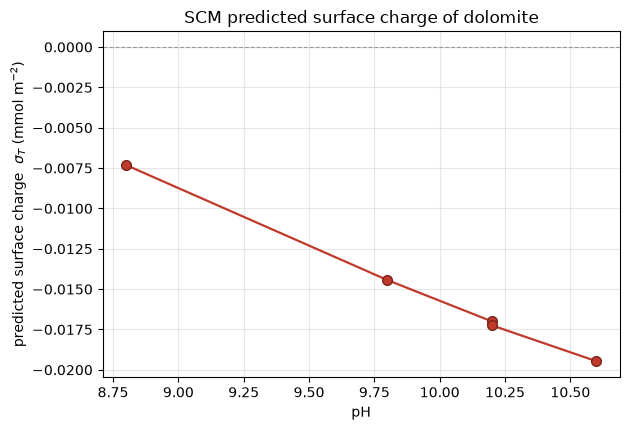

In [5]:
sp = model.sort_values("pH")
fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.axhline(0, color="0.6", lw=0.8, ls="--")
ax.plot(sp["pH"], sp["sigma_T (mmol/m2)"], "-o", color="#c0392b",
        markeredgecolor="#7b241c", lw=1.6, ms=7, zorder=3)
ax.set_xlabel("pH"); ax.set_ylabel(r"predicted surface charge  $\sigma_T$ (mmol m$^{-2}$)")
ax.set_title("SCM predicted surface charge of dolomite")
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

## Surface speciation versus pH

A smooth pH sweep at the median base-run composition, showing how the carbonate and metal surface
species evolve with pH.

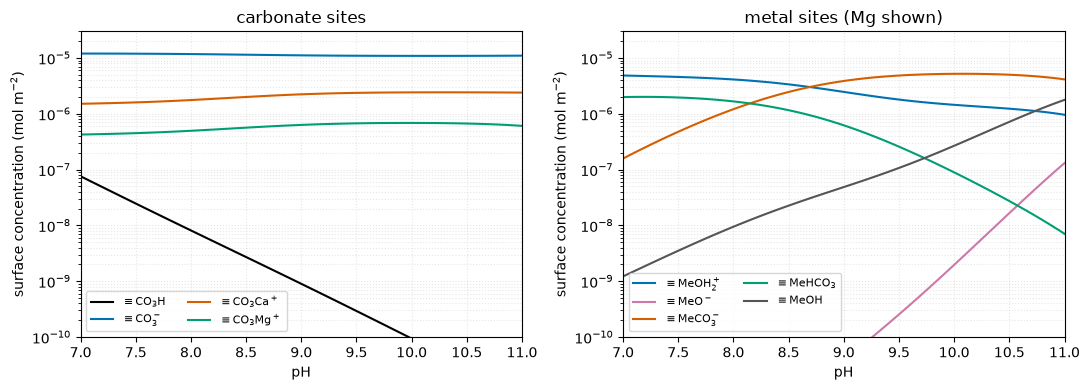

In [6]:
ca_r  = np.median([mol(C[r][1], MW["Ca"]) for r in range(5,10)])
mg_r  = np.median([mol(C[r][2], MW["Mg"]) for r in range(5,10)])
cl_r  = np.median([mol(C[r][4], MW["Cl"]) for r in range(5,10)])
co2_r = np.median([mol(C[r][5], MW["CO3"]) + mol(C[r][6], MW["HCO3"]) for r in range(5,10)])

sweep = []
for pH in np.linspace(7.0, 11.0, 81):
    p = solve_point(float(pH), ca_tot=ca_r, mg_tot=mg_r, nacl=cl_r, sum_co2=co2_r)
    sweep.append({"pH":pH, "sigma_T_mmol_m2":p["sigma_T"]*1e3, **p["surface"]})
sw = pd.DataFrame(sweep)

CARB = [(">CO3H", r"$\equiv$CO$_3$H", "#000000"), (">CO3-", r"$\equiv$CO$_3^-$", "#0072B2"),
        (">CO3Ca+", r"$\equiv$CO$_3$Ca$^+$", "#D55E00"), (">CO3Mg+", r"$\equiv$CO$_3$Mg$^+$", "#009E73")]
MET  = [(">MgOH2+", r"$\equiv$MeOH$_2^+$", "#0072B2"), (">MgO-", r"$\equiv$MeO$^-$", "#CC79A7"),
        (">MgCO3-", r"$\equiv$MeCO$_3^-$", "#D55E00"), (">MgHCO3", r"$\equiv$MeHCO$_3$", "#009E73"),
        (">MgOH", r"$\equiv$MeOH", "#555555")]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for s,l,c in CARB: axes[0].plot(sw.pH, sw[s], color=c, label=l)
for s,l,c in MET:  axes[1].plot(sw.pH, sw[s], color=c, label=l)
for ax, ttl in zip(axes, ["carbonate sites", "metal sites (Mg shown)"]):
    ax.set_yscale("log"); ax.set_ylim(1e-10, 3e-5); ax.set_xlim(7, 11)
    ax.set_xlabel("pH"); ax.set_ylabel(r"surface concentration (mol m$^{-2}$)")
    ax.set_title(ttl); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3, which="both", ls=":")
fig.tight_layout(); plt.show()

## Notes

1. Forward SCM: σ_T is predicted from the six surface reactions and the constant-capacitance layer, not
   from an aqueous charge balance.
2. The point of zero charge appears where the curve crosses zero; above it the surface turns negative as
   deprotonation and carbonate binding dominate.
3. Intrinsic surface constants and site densities are literature values for dolomite; the aqueous model
   uses Davies activity coefficients. At ~1 M ionic strength a Pitzer treatment would be preferable for
   publication values.